# Cu-CPA magnetization (HLD Dresden, March 2025)

[Logbook on Google Docs](https://docs.google.com/document/d/1B_cTC_Fmf2E70vtYpN1luHGj1h5g6fbyWjFoSzNOuJg/edit?usp=sharing)  <br>
Field scaling factor: 0.0044<br>
Magnetization scaling factor: -1

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
%matplotlib notebook

pathstr = os.getcwd()
diagnostic = 1;

def Mread(pathstr, filename, diagnostic=False):
    # Reads the .dat file, performs baseline corrections, integrates the data to get the field and magnetization values
    with open(f"{pathstr}{filename}.dat", "r") as file:
        for i in range(7):
            next(file)
        data = [list(map(float, line.split())) for line in file]
    
    Tpu = np.array(data)
    PU = Tpu[:, 4] # Extract the 5th column - PU (pick-up coil signal)
    times = np.arange(len(PU)) * 1e-6 # Define time vector for a sampling interval of 1 µs
    
    triggered = np.where(PU > 0.5)[0]  # Use PU > 0.5 as a trigger
    t0 = times[triggered[0]] - 0.005  # Reduce trigger time by 5 ms to define t0
    
    fittimes = (times < t0) | (times > times[-1] - 0.005)
    lincoeffs = np.polyfit(times[fittimes], PU[fittimes], 1) # Perform linear fit for PU before t0 and last 5 ms
    PU = PU - (lincoeffs[1] + lincoeffs[0] * times) # Subtract the linear trend from PU
        
    Field = np.cumsum(PU) * 0.0044 # Integrate PU and scale by 0.0044 (in the example code: 0.00756!) to obtain Field
    
    dMdt = Tpu[:, 5] # Extract the 6th column for dM/dt
    lincoeffs = np.polyfit(times[fittimes], dMdt[fittimes], 1) # Perform linear fit for dM/dt before t0 and last 5 ms
    dMdt = dMdt - (lincoeffs[1] + lincoeffs[0] * times)
    
    Magn = np.cumsum(dMdt) * (-1) # Integrate dM/dt to obtain magnetization, scale by -1
    
    Mdata = {
        "H": Field,
        "M": Magn,
    }
    
    maxH_idx = np.argmax(Field) # Find max field index
    # Split data into Up (U) and Down (D) sweeps
    Mdata["U"] = {"H": Field[:maxH_idx+1], "M": Magn[:maxH_idx+1]}
    Mdata["D"] = {"H": Field[maxH_idx:], "M": Magn[maxH_idx:]}
    
    if diagnostic:
        print("Max Field:", np.max(Field))
        
        plt.figure(figsize=(10, 8))
        plt.suptitle(filename, fontsize=10)
        
        plt.subplot(2, 2, 1)
        plt.plot(times, Field, label='Field')
        plt.plot(times, Tpu[:, 0], label='Trigger')
        plt.xlabel('t (sec)')
        plt.ylabel('H (T)')
        plt.legend()
        
        plt.subplot(2, 2, 3)
        plt.plot(times, dMdt)
        plt.xlabel('t (sec)')
        plt.ylabel('dM/dt (arb. u.)')
        
        plt.subplot(2, 2, 2)
        plt.plot(Field, dMdt)
        plt.xlabel('H (T)')
        plt.ylabel('dM/dt (arb. u.)')
        
        plt.subplot(2, 2, 4)
        plt.plot(Mdata["U"]["H"], Mdata["U"]["M"], label='upsweep')
        plt.plot(Mdata["D"]["H"], Mdata["D"]["M"], label='downsweep')
        plt.xlabel('H (T)')
        plt.ylabel('M (arb. u.)')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    return Mdata

def subtract_background(sample, background, diagnostic=False):

    M_sample = Mread(pathstr, sample, diagnostic);
    M_bck = Mread(pathstr, background, diagnostic);
    
    M_sub_U = M_sample["U"]["M"] - interp1d(M_bck["U"]["H"], M_bck["U"]["M"], bounds_error=False)(M_sample["U"]["H"])
    mask_U = np.isfinite(M_sub_U)
    M_sub_D = M_sample["D"]["M"] - interp1d(M_bck["D"]["H"], M_bck["D"]["M"], bounds_error=False)(M_sample["D"]["H"])
    mask_D = np.isfinite(M_sub_D)
    
    # Background subtraction
    subtracted = {
        "U": {
            "H": M_sample["U"]["H"][mask_U],
            "M": M_sub_U[mask_U]
        },
        "D": {
            "H": M_sample["D"]["H"][mask_D],
            "M": M_sub_D[mask_D]
        }
    }

    return subtracted

def derivative(data, window_length, polyorder):
    
    der = np.gradient(data["M"], data["H"])
    
    dM_dH = {
        "H": data["H"],
        "dMdH": savgol_filter(der, window_length, polyorder),
    }
    
    return dM_dH

[Data files on the HZDR cloud](https://cloud.hzdr.de/s/MkqBc9oFArt3rga)<br>
Password: xaQzgAey

In [2]:
#Filenames for the H||b sample with low (4kV) or high (15kV) voltage (i.e. up to 10 T or to 40 T)
f_b_low = [
    '/data/20250314/2025_03_14_18_35_15_DMA17-224_PovarovArh_M3_-4kV_0.44K_22mm_file110.dat',
    '/data/20250314/2025_03_14_16_24_41_DMA17-224_PovarovArh_M3_-4kV_0.57K_22mm_file107.dat',
    '/data/20250314/2025_03_14_15_19_02_DMA17-224_PovarovArh_M3_-4kV_0.68K_22mm_file106.dat',
    '/data/20250314/2025_03_14_10_50_41_DMA17-224_PovarovArh_M3_-4kV_0.68K_22mm_file99.dat'
];

f_b_high = [
    '/data/20250314/2025_03_14_12_03_25_DMA17-224_PovarovArh_M3_-15kV_0.40K_22mm_file101.dat',
    '/data/20250314/2025_03_14_11_14_30_DMA17-224_PovarovArh_M3_-15kV_0.56K_22mm_file100.dat',
    '/data/20250314/2025_03_14_13_05_18_DMA17-224_PovarovArh_M3_-15kV_1.5K_22mm_file102.dat',
    '/data/20250314/2025_03_14_09_01_56_DMA17-224_PovarovArh_M3_-15kV_4K_22mm_file98.dat'
];

#Filenames for the H||a sample with low (4kV) or high (15kV) voltage (i.e. up to 10 T or to 40 T)
f_a_low = [
    '/data/20250314/2025_03_14_18_26_10_DMA17-224_PovarovArh_M3_-4kV_0.43K_3mm_file109.dat'
];

f_a_high = [
    '/data/20250314/2025_03_14_18_52_42_DMA17-224_PovarovArh_M3_-15kV_0.43K_3mm_file111.dat',
    '/data/20250314/2025_03_14_17_06_33_DMA17-224_PovarovArh_M3_-15kV_0.67K_3mm_file108.dat'
];

#Background files
f_bck = [
    '/data/20250314/2025_03_14_14_23_01_DMA17-224_PovarovArh_M3_-4kV_0.48K_32mm_file104.dat',
    '/data/20250314/2025_03_14_14_33_43_DMA17-224_PovarovArh_M3_-15kV_0.52K_32mm_file105.dat', #good
    '/data/20250314/2025_03_14_13_41_46_DMA17-224_PovarovArh_M3_-15kV_0.68K_32mm_file103.dat' #bad
];

## H||a sample

Plotting all the results first. #108 and #109 were measured one after the other (red and black on the plot); #111 (blue) was measured after pulling the stick out and pushing in again.

<IPython.core.display.Javascript object>


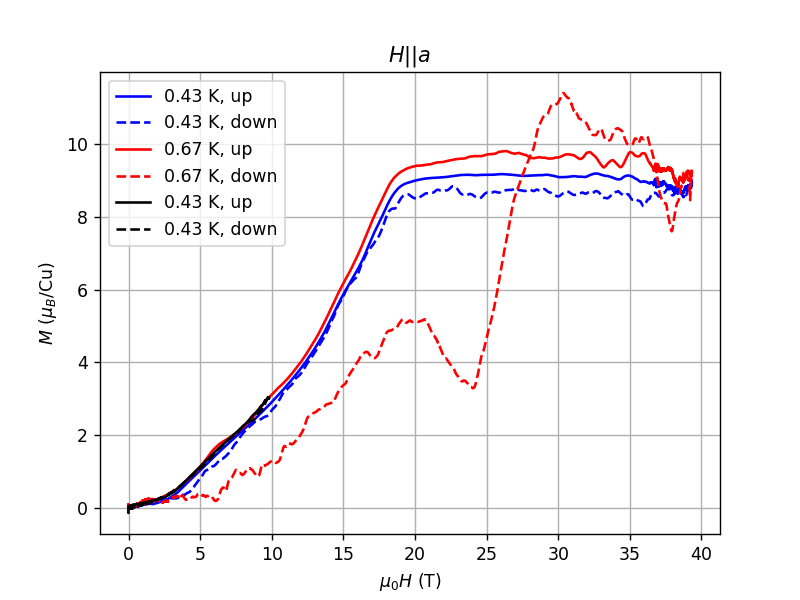

In [3]:
MHresult1 = subtract_background(f_a_high[0], f_bck[1], False) #sample: 111, background: 105
MHresult2 = subtract_background(f_a_high[1], f_bck[1], False) #sample: 108, background: 105
MHresult3 = subtract_background(f_a_low[0], f_bck[0], False) #sample: 109, background: 104

plt.figure()
plt.plot(MHresult1["U"]["H"], MHresult1["U"]["M"], 'b-', label="0.43 K, up")
plt.plot(MHresult1["D"]["H"], MHresult1["D"]["M"], 'b--', label="0.43 K, down")
plt.plot(MHresult2["U"]["H"], MHresult2["U"]["M"], 'r-', label="0.67 K, up")
plt.plot(MHresult2["D"]["H"], MHresult2["D"]["M"], 'r--', label="0.67 K, down")
plt.plot(MHresult3["U"]["H"], MHresult3["U"]["M"], 'k-', label="0.43 K, up")
plt.plot(MHresult3["D"]["H"], MHresult3["D"]["M"], 'k--', label="0.43 K, down")
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$M$ ($\\mu_B$/Cu)")
plt.title("$H||a$")
plt.legend()
plt.grid()
plt.show()

# Save data
#np.savetxt("M_vs_H_111minus105_UpSweep.txt", np.column_stack((MHresult["U"]["H"], MHresult["U"]["M"])), delimiter="\t")
#np.savetxt("M_vs_H_111minus105_DownSweep.txt", np.column_stack((MHresult["D"]["H"], MHresult["D"]["M"])), delimiter="\t")

The weird downsweep in 0.67 K measurement makes it suspicious. Only plotting upsweep now:

<IPython.core.display.Javascript object>


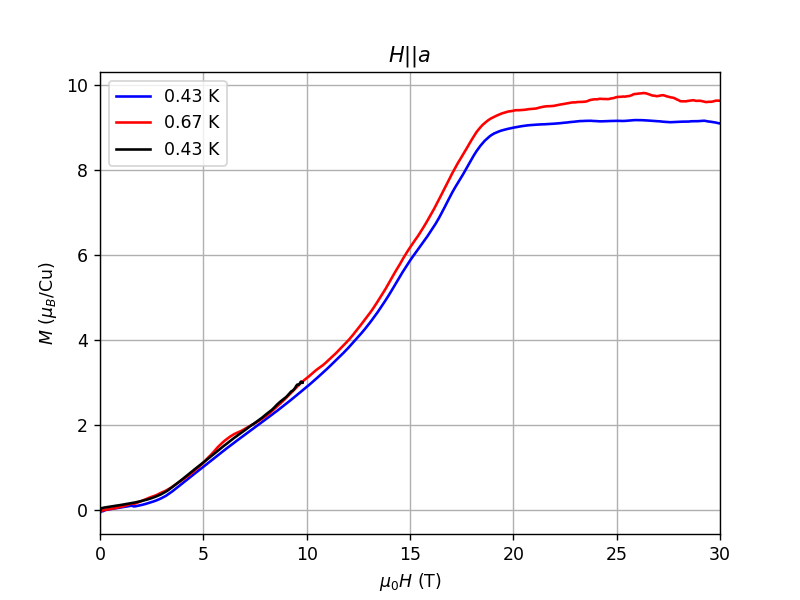

In [4]:
plt.figure()
plt.plot(MHresult1["U"]["H"], MHresult1["U"]["M"], 'b-', label="0.43 K")
plt.plot(MHresult2["U"]["H"], MHresult2["U"]["M"], 'r-', label="0.67 K")
plt.plot(MHresult3["U"]["H"], MHresult3["U"]["M"], 'k-', label="0.43 K")
plt.xlim(0,30)
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$M$ ($\\mu_B$/Cu)")
plt.title("$H||a$")
plt.legend()
plt.grid()
plt.show()

Calculating derivatives and smoothing them with a filter:

<IPython.core.display.Javascript object>


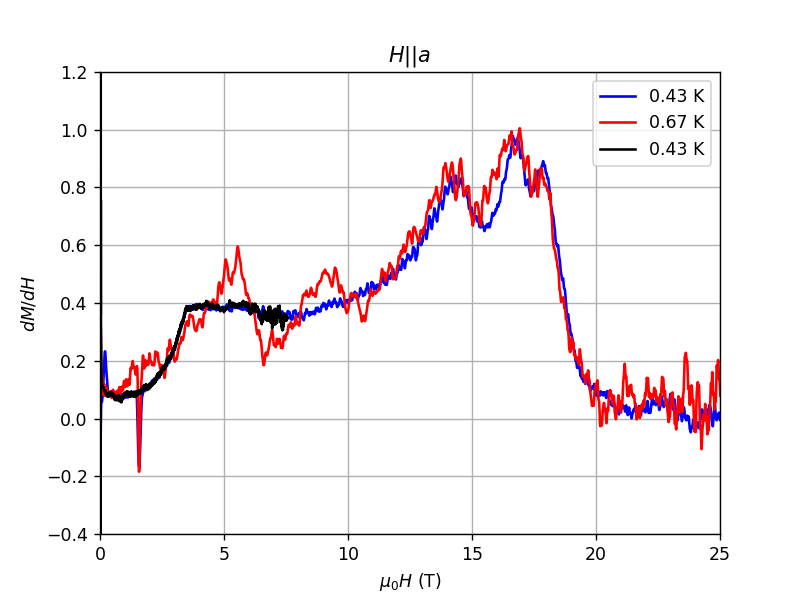

<IPython.core.display.Javascript object>


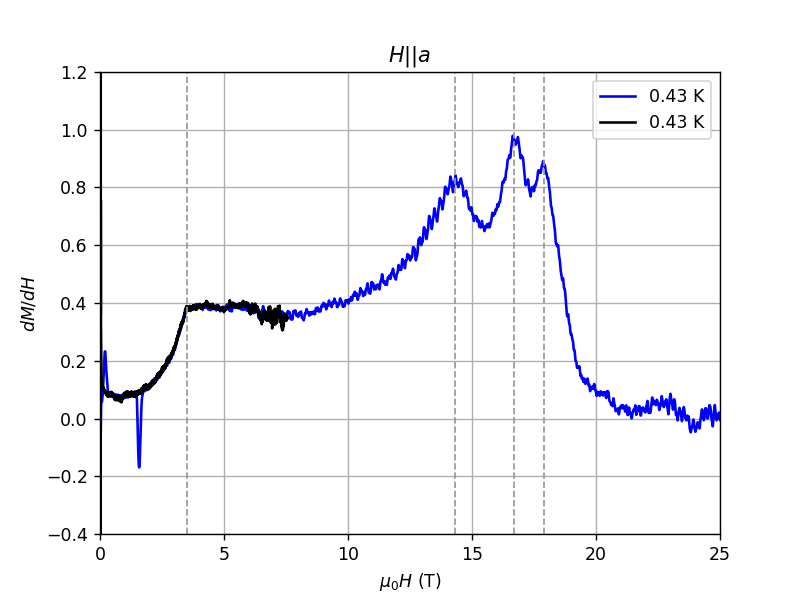

In [5]:
dM_dH1 = derivative(MHresult1["U"], 10, 1)
dM_dH2 = derivative(MHresult2["U"], 5, 1)
dM_dH3 = derivative(MHresult3["U"], 50, 1)

plt.figure()
plt.plot(dM_dH1["H"], dM_dH1["dMdH"], 'b-', label="0.43 K")
plt.plot(dM_dH2["H"], dM_dH2["dMdH"], 'r-', label="0.67 K")
plt.plot(dM_dH3["H"][:24000], dM_dH3["dMdH"][:24000], 'k-', label="0.43 K")
plt.xlim(0, 25)
plt.ylim(-0.4, 1.2)
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$dM/dH$")
plt.title("$H||a$")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(dM_dH1["H"], dM_dH1["dMdH"], 'b-', label="0.43 K")
plt.plot(dM_dH3["H"][:24000], dM_dH3["dMdH"][:24000], 'k-', label="0.43 K")
plt.plot([3.5, 3.5], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.plot([14.3, 14.3], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.plot([16.7, 16.7], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.plot([17.9, 17.9], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.xlim(0,25)
plt.ylim(-0.4,1.2)
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$dM/dH$")
plt.title("$H||a$")
plt.legend()
plt.grid()
plt.show()

There is clearly a gap of around H_c1 = 3.5 T. Perhaps more interestingly, we have three features at 14.3 T, 16.7 T, and 17.9 T which we also see in the 0.67 K measurement.

## H||b sample

Plotting the high- and the low-field results separately. #98 - #102 were measured one after the other; #106 and #107 after pulling the stick out for background and pushing it in again; and #110 after measuring H||a sample (pushing all the way in and pulling back out).

In [6]:
MHresult4 = subtract_background(f_b_high[0], f_bck[1], False) #sample: 101, background: 105
MHresult5 = subtract_background(f_b_high[1], f_bck[1], False) #sample: 100, background: 105
MHresult6 = subtract_background(f_b_high[2], f_bck[1], False) #sample: 102, background: 105
MHresult7 = subtract_background(f_b_high[3], f_bck[1], False) #sample: 98, background: 105
MHresult8 = subtract_background(f_b_low[0], f_bck[0], False) #sample: 110, background: 104
MHresult9 = subtract_background(f_b_low[1], f_bck[0], False) #sample: 107, background: 104
MHresult10 = subtract_background(f_b_low[2], f_bck[0], False) #sample: 106, background: 104
MHresult11 = subtract_background(f_b_low[3], f_bck[0], False) #sample: 99, background: 104

<IPython.core.display.Javascript object>


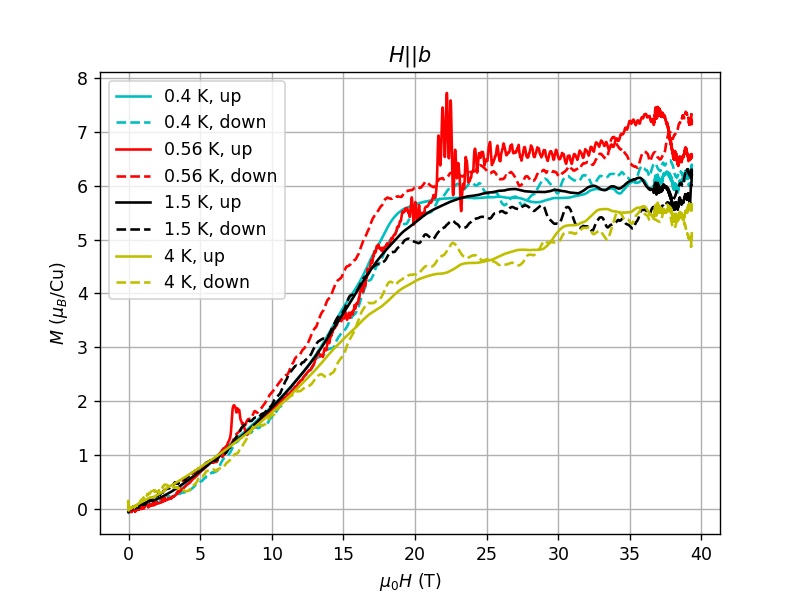

In [7]:
plt.figure()
plt.plot(MHresult4["U"]["H"], MHresult4["U"]["M"], 'c-', label="0.4 K, up")
plt.plot(MHresult4["D"]["H"], MHresult4["D"]["M"], 'c--', label="0.4 K, down")
plt.plot(MHresult5["U"]["H"], MHresult5["U"]["M"], 'r-', label="0.56 K, up")
plt.plot(MHresult5["D"]["H"], MHresult5["D"]["M"], 'r--', label="0.56 K, down")
plt.plot(MHresult6["U"]["H"], MHresult6["U"]["M"], 'k-', label="1.5 K, up")
plt.plot(MHresult6["D"]["H"], MHresult6["D"]["M"], 'k--', label="1.5 K, down")
plt.plot(MHresult7["U"]["H"], MHresult7["U"]["M"], 'y-', label="4 K, up")
plt.plot(MHresult7["D"]["H"], MHresult7["D"]["M"], 'y--', label="4 K, down")
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$M$ ($\\mu_B$/Cu)")
plt.title("$H||b$")
plt.legend()
plt.grid()
plt.show()

Something went wrong with the 0.56 K measurement.

<IPython.core.display.Javascript object>


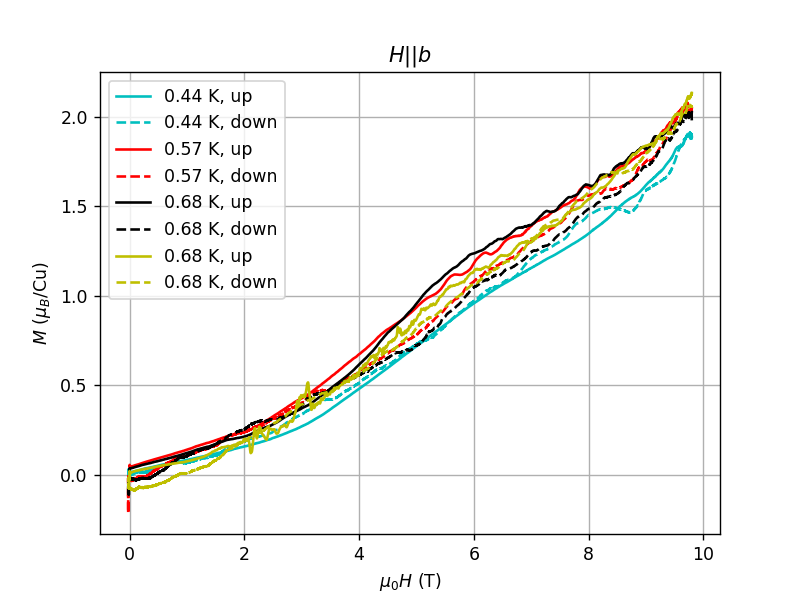

In [8]:
plt.figure()
plt.plot(MHresult8["U"]["H"], MHresult8["U"]["M"], 'c-', label="0.44 K, up")
plt.plot(MHresult8["D"]["H"], MHresult8["D"]["M"], 'c--', label="0.44 K, down")
plt.plot(MHresult9["U"]["H"], MHresult9["U"]["M"], 'r-', label="0.57 K, up")
plt.plot(MHresult9["D"]["H"], MHresult9["D"]["M"], 'r--', label="0.57 K, down")
plt.plot(MHresult10["U"]["H"], MHresult10["U"]["M"], 'k-', label="0.68 K, up")
plt.plot(MHresult10["D"]["H"], MHresult10["D"]["M"], 'k--', label="0.68 K, down")
plt.plot(MHresult11["U"]["H"], MHresult11["U"]["M"], 'y-', label="0.68 K, up")
plt.plot(MHresult11["D"]["H"], MHresult11["D"]["M"], 'y--', label="0.68 K, down")
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$M$ ($\\mu_B$/Cu)")
plt.title("$H||b$")
plt.legend()
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


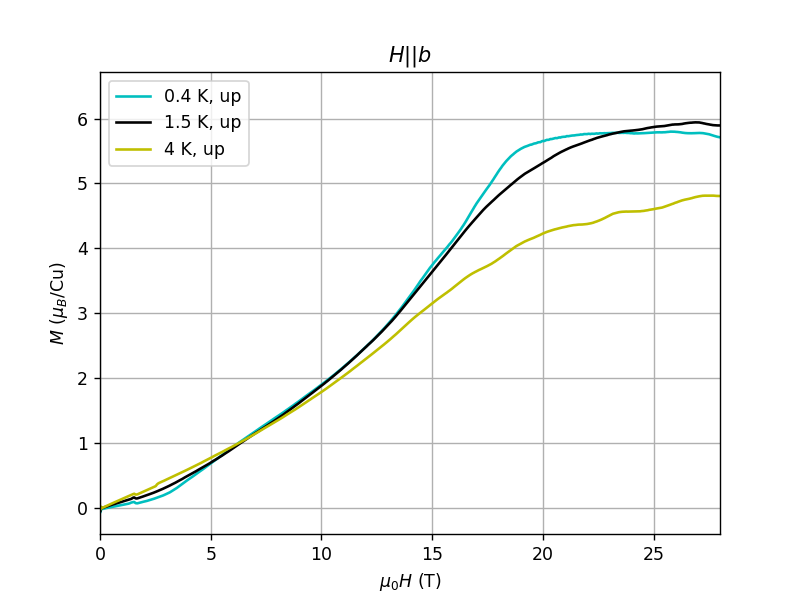

In [9]:
plt.figure()
plt.plot(MHresult4["U"]["H"], MHresult4["U"]["M"], 'c-', label="0.4 K, up")
#plt.plot(MHresult5["U"]["H"], MHresult5["U"]["M"], 'r-', label="0.56 K, up")
plt.plot(MHresult6["U"]["H"], MHresult6["U"]["M"], 'k-', label="1.5 K, up")
plt.plot(MHresult7["U"]["H"], MHresult7["U"]["M"], 'y-', label="4 K, up")
plt.xlim(0,28)
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$M$ ($\\mu_B$/Cu)")
plt.title("$H||b$")
plt.legend()
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


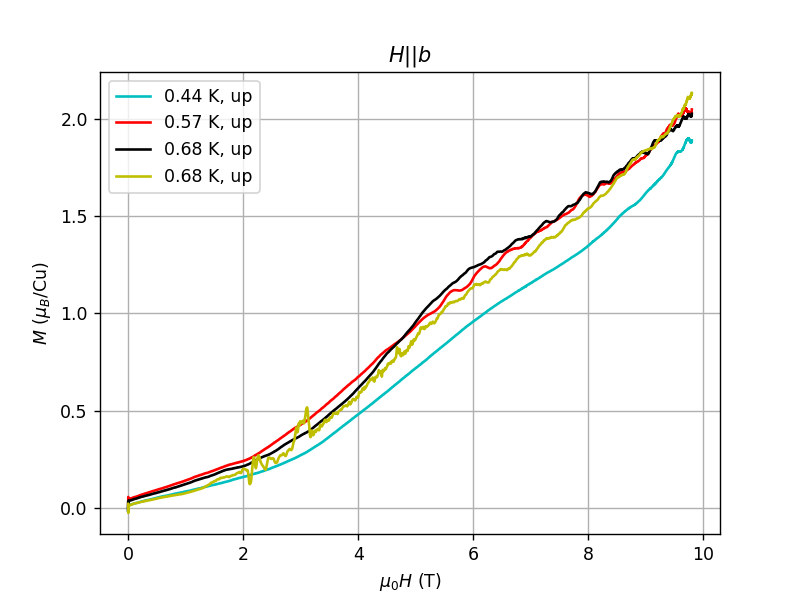

In [10]:
plt.figure()
plt.plot(MHresult8["U"]["H"], MHresult8["U"]["M"], 'c-', label="0.44 K, up")
plt.plot(MHresult9["U"]["H"], MHresult9["U"]["M"], 'r-', label="0.57 K, up")
plt.plot(MHresult10["U"]["H"], MHresult10["U"]["M"], 'k-', label="0.68 K, up")
plt.plot(MHresult11["U"]["H"], MHresult11["U"]["M"], 'y-', label="0.68 K, up")
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$M$ ($\\mu_B$/Cu)")
plt.title("$H||b$")
plt.legend()
plt.grid()
plt.show()

In [11]:
dM_dH4 = derivative(MHresult4["U"], 15, 1)
dM_dH5 = derivative(MHresult5["U"], 15, 1)
dM_dH6 = derivative(MHresult6["U"], 15, 1)
dM_dH7 = derivative(MHresult7["U"], 15, 1)
dM_dH8 = derivative(MHresult8["U"], 50, 1)
dM_dH9 = derivative(MHresult9["U"], 50, 1)
dM_dH10 = derivative(MHresult10["U"], 50, 1)
dM_dH11 = derivative(MHresult11["U"], 50, 1)

<IPython.core.display.Javascript object>


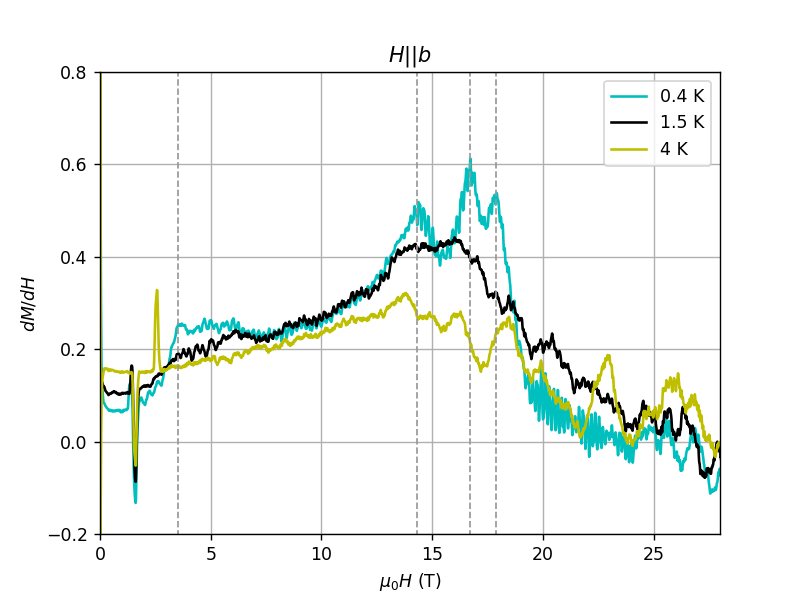

In [12]:
plt.figure()
plt.plot(dM_dH4["H"], dM_dH4["dMdH"], 'c-', label="0.4 K")
#plt.plot(dM_dH5["H"], dM_dH5["dMdH"], 'r-', label="0.56 K")
plt.plot(dM_dH6["H"], dM_dH6["dMdH"], 'k-', label="1.5 K")
plt.plot(dM_dH7["H"], dM_dH7["dMdH"], 'y-', label="4 K")
plt.plot([3.5, 3.5], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.plot([14.3, 14.3], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.plot([16.7, 16.7], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.plot([17.9, 17.9], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.xlim(0,28)
plt.ylim(-0.2,0.8)
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$dM/dH$")
plt.title("$H||b$")
plt.legend()
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


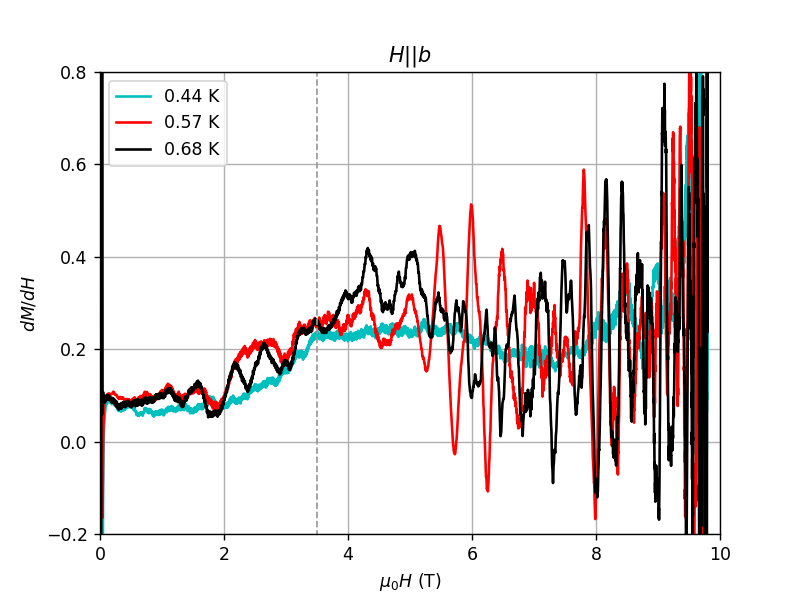

In [13]:
plt.figure()
plt.plot(dM_dH8["H"], dM_dH8["dMdH"], 'c-', label="0.44 K")
plt.plot(dM_dH9["H"], dM_dH9["dMdH"], 'r-', label="0.57 K")
plt.plot(dM_dH10["H"], dM_dH10["dMdH"], 'k-', label="0.68 K")
#plt.plot(dM_dH11["H"], dM_dH11["dMdH"], 'y-', label="0.68 K")
plt.plot([3.5, 3.5], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.xlim(0,10)
plt.ylim(-0.2,0.8)
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$dM/dH$")
plt.title("$H||b$")
plt.legend()
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


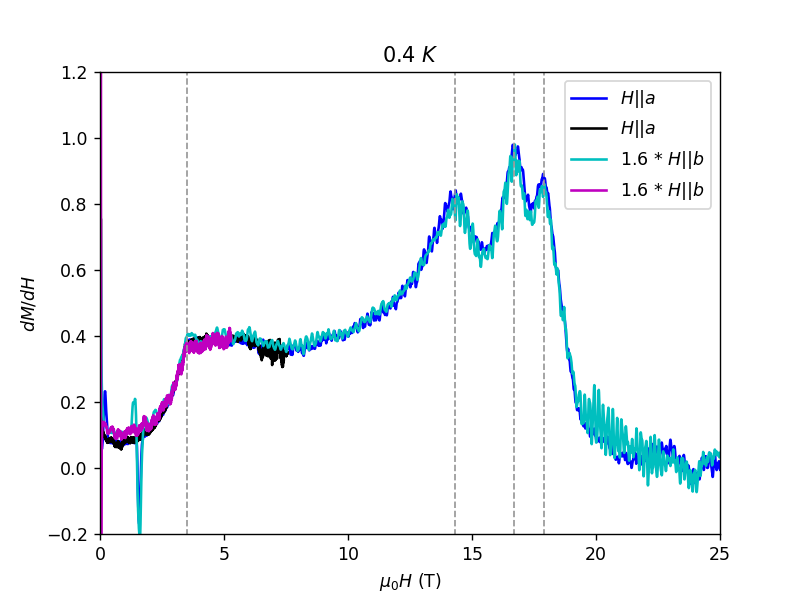

In [15]:
plt.figure()
plt.plot(dM_dH1["H"], dM_dH1["dMdH"], 'b-', label="$H||a$")
plt.plot(dM_dH3["H"][:24000], dM_dH3["dMdH"][:24000], 'k-', label="$H||a$")
plt.plot(dM_dH4["H"], 1.6*dM_dH4["dMdH"], 'c-', label="1.6 * $H||b$")
plt.plot(dM_dH8["H"][:21500], 1.6*dM_dH8["dMdH"][:21500], 'm-', label="1.6 * $H||b$")
plt.plot([3.5, 3.5], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.plot([14.3, 14.3], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.plot([16.7, 16.7], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.plot([17.9, 17.9], [-0.4, 1.2],'--', color = '0.6', linewidth = 1)
plt.xlim(0,25)
plt.ylim(-0.2,1.2)
plt.xlabel("$\\mu_0 H$ (T)")
plt.ylabel("$dM/dH$")
plt.title("$0.4~K$")
plt.legend()
#plt.grid()
plt.show()

Very isotropic behavior, consistent across two different samples.